In [1]:
import numpy as np
np.float = float
import random
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder

In [3]:
# loading and preparing the data
reviews = pd.read_json("/Users/jasperbruin/Documents/driftwatch/LAB experiments/datasets/Amazon_Fashion.jsonl", lines=True)
reviews = reviews[reviews["rating"] != 3]
reviews = reviews[reviews["timestamp"] > "2015-01-01"]
reviews["year"] = reviews["timestamp"].apply(lambda x: x.year)
reviews["month"] = reviews["timestamp"].apply(lambda x: x.month)
reviews["day"] = reviews["timestamp"].apply(lambda x: x.day)

In [4]:
#create reference dataframe
reference_data = reviews[reviews["timestamp"] > "2015-01-01"]
reference_data = reference_data[reference_data["timestamp"] < "2020-01-01"]
#create evaluation dataframe
evaluation_data = reviews[reviews["timestamp"] >= "2020-01-01"]
evaluation_data = evaluation_data.set_index(evaluation_data["timestamp"])
evaluation_data.sort_index(inplace = True)

In [5]:
# remove products that appear after ref
evaluation_data_with_old_products = evaluation_data[evaluation_data["parent_asin"].isin(reference_data["parent_asin"])]

In [6]:
#create rolling window
rolling = evaluation_data_with_old_products["rating"].rolling("30D").mean()

In [7]:
#encode features in the reviews for use in ml model
sparse_features = ["parent_asin", "user_id","year","month","day"]
for feat in sparse_features:
        lbe = LabelEncoder()
        reviews[feat] = lbe.fit_transform(reviews[feat])

In [8]:
def create_matrix(df):
	
	N = len(df['user_id'].unique())
	M = len(df['product_id'].unique())
	
	# Map Ids to indices
	user_mapper = dict(zip(np.unique(df["user_id"]), list(range(N))))
	product_mapper = dict(zip(np.unique(df["product_id"]), list(range(M))))
	
	# Map indices to IDs
	user_inv_mapper = dict(zip(list(range(N)), np.unique(df["user_id"])))
	product_inv_mapper = dict(zip(list(range(M)), np.unique(df["product_id"])))
	
	user_index = [user_mapper[i] for i in df['user_id']]
	product_index = [product_mapper[i] for i in df['product_id']]

	X = csr_matrix((df["rating"], (product_index, user_index)), shape=(M, N))
	
	return X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper

In [9]:
#rename for use in function
reference_data["product_id"] = reference_data["parent_asin"]

In [10]:
X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper = create_matrix(reference_data)

In [11]:
#train ml model
kNN = NearestNeighbors(n_neighbors=5, algorithm="brute", metric='cosine')
kNN.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine')

In [12]:
def find_similar_products(product_id, X, k, metric='cosine', show_distance=False):

  neighbour_ids = []

  product_ind = product_mapper[product_id]
  product_vec = X[product_ind]
  k+=1
  product_vec = product_vec.reshape(1,-1)
  neighbour = kNN.kneighbors(product_vec, return_distance=show_distance)
  for i in range(0,k):
    n = neighbour.item(i)
    neighbour_ids.append(product_inv_mapper[n])
  neighbour_ids.pop(0)
  return neighbour_ids

In [13]:
#sample reviews from products
sampled = evaluation_data_with_old_products.sample(10000)

In [14]:
sampled.sort_index(inplace=True)

In [15]:
rolling = sampled["rating"].rolling("30D").mean()

In [16]:
#store the predictions of the recommendation system (takes a long time)
preds = []
for i in range(len(sampled)):
    preds.append(find_similar_products(sampled["parent_asin"].values[i],X,4))

In [17]:
preds

[['B078MXCQHN', 'B078MX3DCB', 'B078MXDYVM', 'B078MX6H1B'],
 ['B078MXDYVM', 'B078MXNPWN', 'B078MXDQ74', 'B078MXT4Z2'],
 ['B07NBV4R6Y', 'B078MXCQHN', 'B078MXDYVM', 'B078MXNQ8B'],
 ['B078MX6H1B', 'B078MWYD5C', 'B078MXDQ74', 'B078MX3DCB'],
 ['B078MXCQHN', 'B078MX3DCB', 'B078MXDYVM', 'B078MX6H1B'],
 ['B078MX3DCB', 'B078MXDQ74', 'B078MX6H1B', 'B078MXDYVM'],
 ['B075M68GLW', 'B072XVRN3N', 'B07666JK2Z', 'B01G3DYQV6'],
 ['B07D5NJRB4', 'B07QXXCJT1', 'B06X9JPHY3', 'B07JHJQ585'],
 ['B01IEKOXSW', 'B078MXDQ74', 'B078MXNPWN', 'B078MXCQHN'],
 ['B019YNGGDS', 'B078MXCQHN', 'B078MXDQ74', 'B078MXNPWN'],
 ['B078MXCQHN', 'B078MX3DCB', 'B078MXDYVM', 'B078MX6H1B'],
 ['B076MYYDLZ', 'B078MXDYVM', 'B078MXNQ8B', 'B078MXDQ74'],
 ['B078MWYD5C', 'B078MX3DCB', 'B078MXCQHN', 'B078MXDYVM'],
 ['B078MX3DCB', 'B078MXDQ74', 'B078MX6H1B', 'B078MXNPWN'],
 ['B07QNXD923', 'B097JVG151', 'B01IH4AVCM', 'B078MWVX47'],
 ['B078MXDQ74', 'B078MX6H1B', 'B078MXCQHN', 'B078MXNQ8B'],
 ['B07K6C6C7L', 'B07G3Z2JFZ', 'B01EWYQHHE', 'B07GVH6G7W'

In [18]:
#store the recommendations in dataframe
sampled["recommendation"] = preds

In [19]:
reviews_copy = pd.read_json("/Users/jasperbruin/Documents/driftwatch/LAB experiments/datasets/Amazon_Fashion.jsonl", lines=True)

In [20]:
#ensure same strutcture as ctr-predictor training data
reviews_copy = reviews_copy[reviews_copy["rating"] != 3]
reviews_copy = reviews_copy[reviews_copy["timestamp"] > "2015-01-01"]

In [21]:
# create a mapper for the ctr-predictor
fashion_mapper = dict(zip(reviews_copy["parent_asin"].unique(), reviews["parent_asin"].unique()))

In [22]:
# create a mapper for the ctr-predictor
fashion_user_mapper = dict(zip(reviews_copy["user_id"].unique(), reviews["user_id"].unique()))

In [23]:
# load the ctr-predictor
model = torch.load("/Users/jasperbruin/Documents/driftwatch/LAB experiments/models/model_formatted_fashion_cpu_v2")

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/4038644545.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/Users/jasperbruin/Docume

In [24]:
# calculate click-through-rate for the recommendations
def mean_predicted_ctr():
    res = []
    for i in range(len(sampled)):
        temp = []
        for j in range(len(sampled["recommendation"][i])):
            temp.append(model.predict({"parent_asin": pd.Series(fashion_mapper[sampled["recommendation"][i][j]]),"user_id": pd.Series(fashion_user_mapper[sampled["user_id"][i]]), "year": pd.Series(sampled["year"][i] - 2015), "month": pd.Series(sampled["month"][i] - 1), "day": pd.Series(sampled["day"][i] - 1)}))
        res.append(temp)    
    return res

In [25]:
ctr_list = mean_predicted_ctr()

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/228874770.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for j in range(len(sampled["recommendation"][i])):
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/228874770.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp.append(model.predict({"parent_asin": pd.Series(fashion_mapper[sampled["recommendation"][i][j]]),"user_id": pd.Series(fashion_user_mapper[sampled["user_id"][i]]), "year": pd.Series(sampled["year"][i] - 2015), "month": pd.Series(sampled["month"][i] - 1), "day": pd.Series(sampled["day"][i] - 1)}))


In [26]:
ctr_list

[[array([[9.75440125e-05]]),
  array([[0.78791863]]),
  array([[0.85150099]]),
  array([[0.83648396]])],
 [array([[0.85150099]]),
  array([[0.98240924]]),
  array([[0.58074945]]),
  array([[0.68237031]])],
 [array([[0.83571053]]),
  array([[0.00104207]]),
  array([[0.99996531]]),
  array([[0.99944013]])],
 [array([[0.97589874]]),
  array([[0.97997379]]),
  array([[0.81672257]]),
  array([[0.94851118]])],
 [array([[0.00104923]]),
  array([[0.00128288]]),
  array([[0.00160288]]),
  array([[0.00112731]])],
 [array([[0.01865012]]),
  array([[0.00543073]]),
  array([[0.02110951]]),
  array([[0.02863473]])],
 [array([[0.99758315]]),
  array([[0.97505206]]),
  array([[0.99870467]]),
  array([[0.56163794]])],
 [array([[0.9948597]]),
  array([[0.99322033]]),
  array([[0.64846879]]),
  array([[0.99999976]])],
 [array([[0.99996924]]),
  array([[0.99989653]]),
  array([[0.99999666]]),
  array([[0.00137962]])],
 [array([[0.23120746]]),
  array([[9.75440125e-05]]),
  array([[0.58074945]]),
  array([

In [27]:
means = []
for i in range(len(ctr_list)):
    means.append(np.mean(ctr_list[i]))

In [28]:
series_means = pd.Series(means, index=sampled["timestamp"])

In [29]:
rolling_means = series_means.rolling("30D").mean()

<Axes: xlabel='timestamp'>

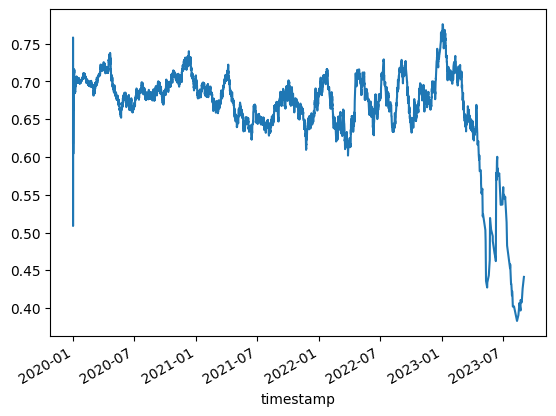

In [30]:
rolling_means.plot()

In [31]:
# create labels for the drift-detectors
correct_recommendations = []
for i in range(len(ctr_list)):
    for j in range(4):
        correct_recommendations.append(random.choices([0,1],weights=[1-ctr_list[i][j][0][0],ctr_list[i][j][0][0]])[0])

In [37]:
# testing the different erb-detectors
print(f"count of correct recommendations: {sum(correct_recommendations)}")

count of correct recommendations: 27351


In [64]:
from river import drift

adwin = drift.ADWIN(delta=0.1, min_window_length=30)

entry_number = 0
entries = []

for i in range(len(correct_recommendations)):
    # Use the `update` method instead of `add_element`
    adwin.update(correct_recommendations[i])
    
    # Check the `drift_detected` property
    if adwin.drift_detected:
        print(f"Change detected in data: {correct_recommendations[i]} - at index: {i} - at entry: {entry_number}")
        entries.append(entry_number)
    
    if i % 4 == 3:
        entry_number += 1


Change detected in data: 1 - at index: 543 - at entry: 135
Change detected in data: 1 - at index: 1759 - at entry: 439
Change detected in data: 0 - at index: 11519 - at entry: 2879
Change detected in data: 1 - at index: 29375 - at entry: 7343
Change detected in data: 1 - at index: 34623 - at entry: 8655
Change detected in data: 0 - at index: 37311 - at entry: 9327
Change detected in data: 1 - at index: 37727 - at entry: 9431
Change detected in data: 1 - at index: 38271 - at entry: 9567
Change detected in data: 1 - at index: 39743 - at entry: 9935


In [65]:
for i in entries:
    print(sampled["timestamp"][i])

2020-01-03 22:18:14.695000
2020-01-10 00:28:19.589000
2020-05-04 23:01:38.456000
2021-07-12 20:35:14.811000
2022-03-20 00:30:13.882000
2022-10-06 20:23:17.148000
2022-11-05 13:06:34.786000
2022-12-14 18:28:07.587000
2023-04-24 01:49:48.526000


/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/3355999057.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(sampled["timestamp"][i])


In [66]:
first_drift = np.datetime64('2021-04-13')

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/2492517066.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axvline(sampled["timestamp"][i], color='r', linestyle='--')


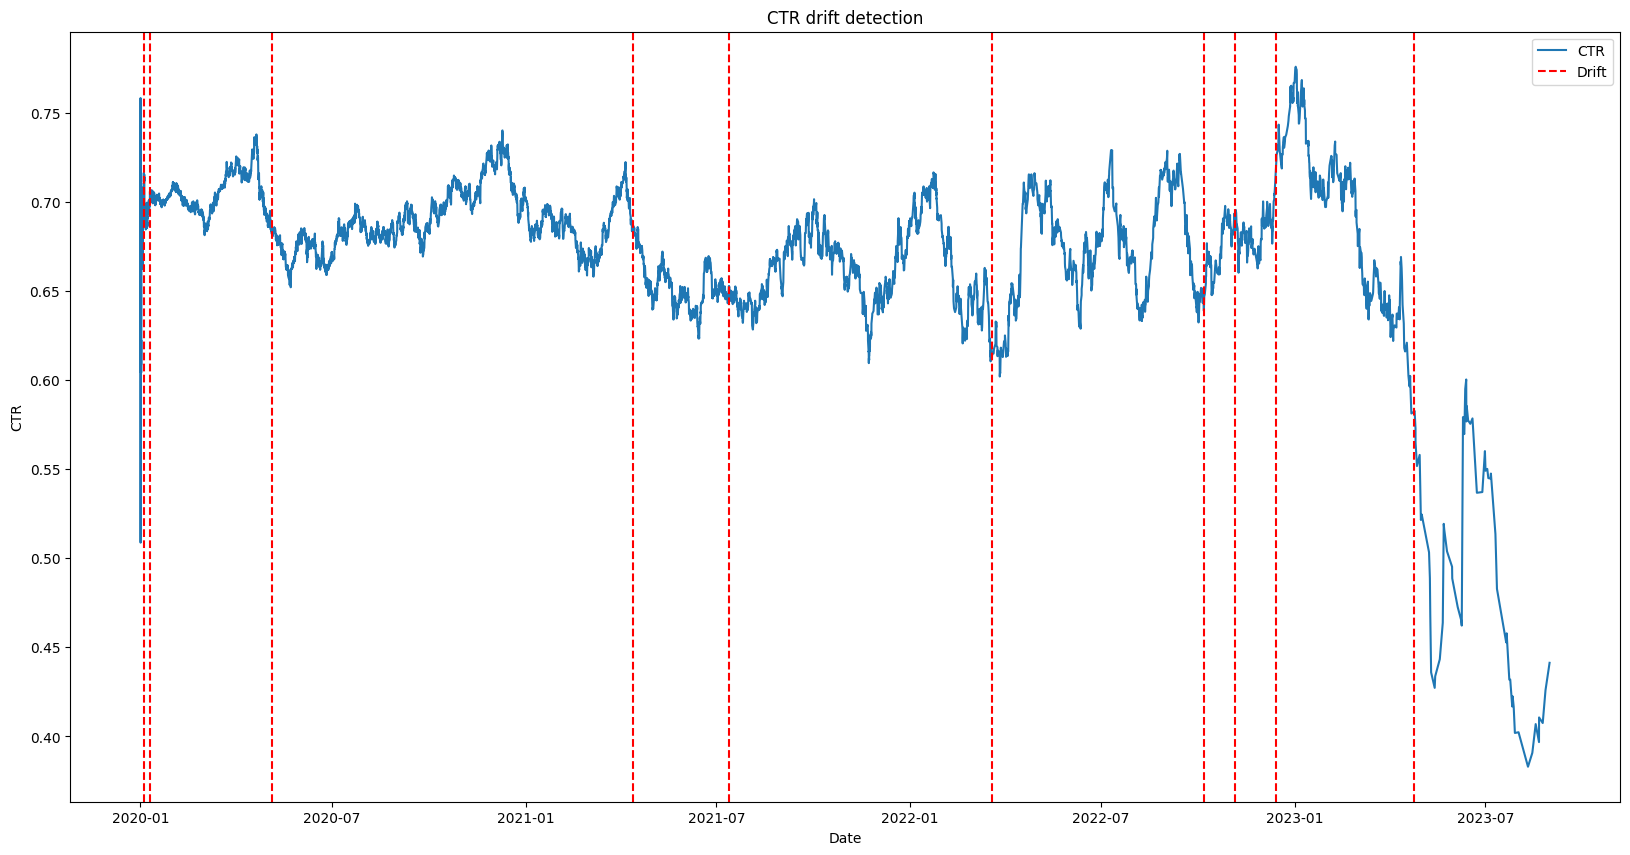

In [67]:
# plot the drifts
plt.figure(figsize=(20,10))
plt.plot(rolling_means)
plt.axvline(first_drift, color='r', linestyle='--')
# plot the other drifts
for i in entries:
    plt.axvline(sampled["timestamp"][i], color='r', linestyle='--')
plt.legend(['CTR', 'Drift'])


plt.title('CTR drift detection')
plt.xlabel('Date')
plt.ylabel('CTR')

plt.show()

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75015/1064746086.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "timestamp": pd.date_range(start="2023-01-01", periods=1000, freq="H"),


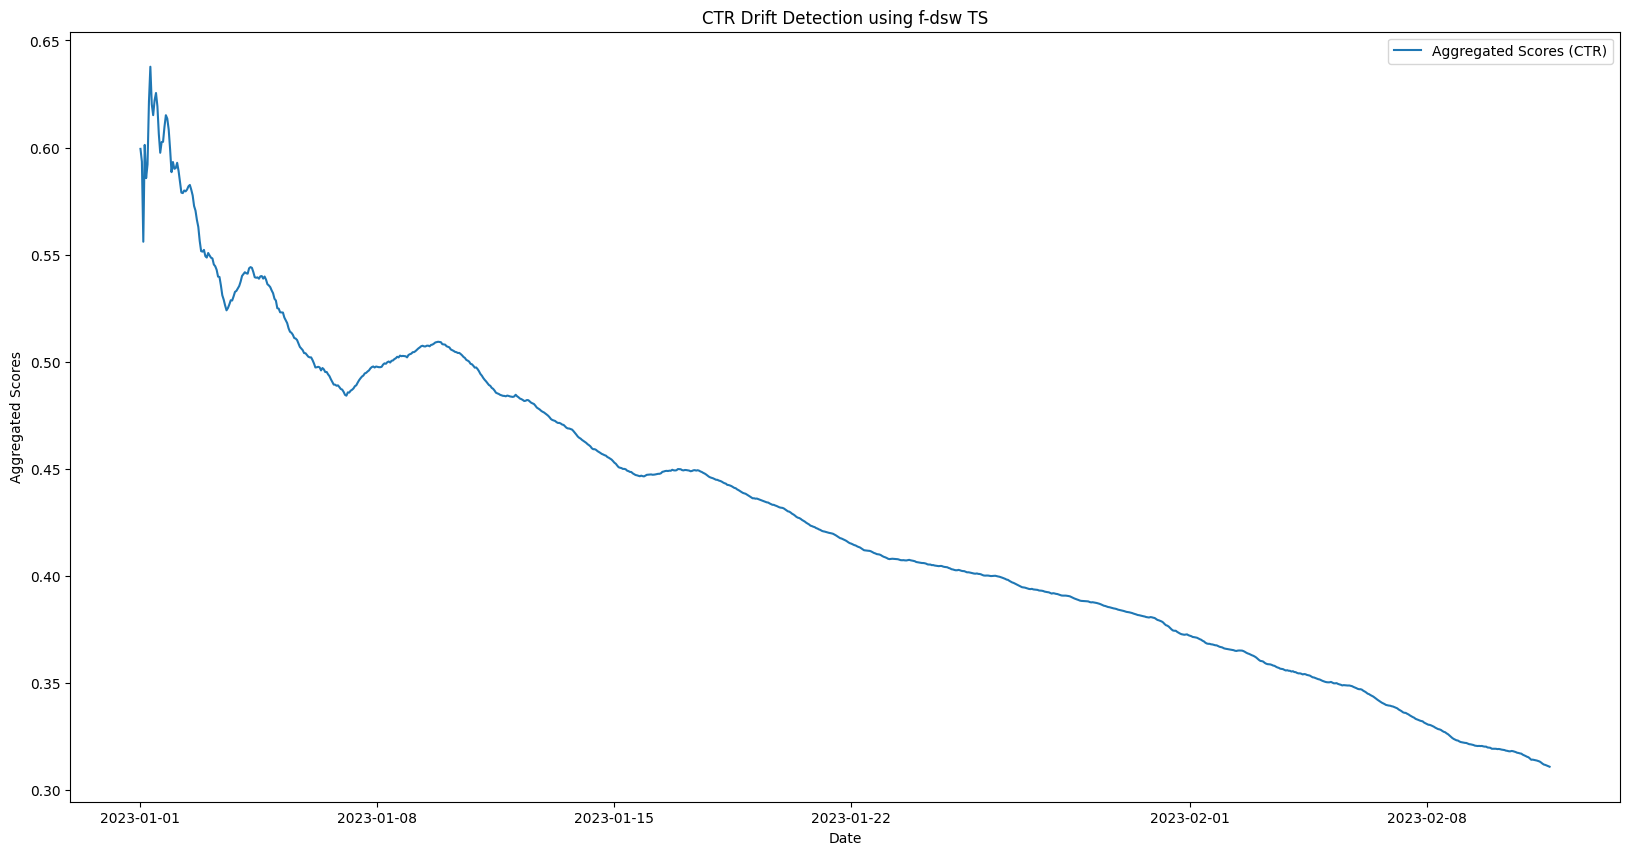